# 回测

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import matplotlib.font_manager as fm
from sklearn.linear_model import LinearRegression
import warnings 

In [2]:
# 忽略警告
warnings.filterwarnings('ignore')
#添加字体配置
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]  #"SimHei",
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常

In [3]:
def backtest_monthly_strategy_with_trades(test_df, top_n=10, benchmark_returns=None, rf=0.0):
    test_df = test_df.copy()
    test_df['month'] = test_df['date'].dt.to_period('M')
    
    monthly_returns = []
    buy_records = []
    sell_records = []

    prev_holdings = set()

    for month, group in test_df.groupby('month'):
        # 当前月买入 top N 股票
        top_stocks = group.sort_values(by='prediction', ascending=False).head(top_n)
        current_holdings = set(top_stocks['code'])

        # 买入记录
        buy_list = list(current_holdings - prev_holdings)
        for code in buy_list:
            buy_records.append({'month': month.to_timestamp(), 'code': code})

        # 卖出记录（上月有持仓但本月不再持有）
        sell_list = list(prev_holdings - current_holdings)
        for code in sell_list:
            sell_records.append({'month': month.to_timestamp(), 'code': code})

        # 收益记录
        avg_return = top_stocks['fwd_return'].mean()
        monthly_returns.append({'month': month.to_timestamp(), 'strategy_return': avg_return})

        prev_holdings = current_holdings

    # 保存买入和卖出记录
    buy_df = pd.DataFrame(buy_records)
    sell_df = pd.DataFrame(sell_records)
    buy_df.to_csv('buy_records.csv', index=False)
    sell_df.to_csv('sell_records.csv', index=False)

    # 净值计算与可视化
    perf_df = pd.DataFrame(monthly_returns).set_index('month')
    if benchmark_returns is not None:
        perf_df['benchmark_return'] = benchmark_returns.loc[perf_df.index]

    perf_df['strategy_nav'] = (1 + perf_df['strategy_return']).cumprod()
    if 'benchmark_return' in perf_df.columns:
        perf_df['benchmark_nav'] = (1 + perf_df['benchmark_return']).cumprod()

    excess_returns = perf_df['strategy_return'] - rf / 12
    sharpe = excess_returns.mean() / excess_returns.std() * np.sqrt(12)
    max_drawdown = (perf_df['strategy_nav'] / perf_df['strategy_nav'].cummax() - 1).min()
    total_months = len(perf_df)
    annualized_return = (perf_df['strategy_nav'].iloc[-1]) ** (12 / total_months) - 1
    win_rate = (perf_df['strategy_return'] > 0).mean()

    print(f"策略夏普比率: {sharpe:.2f}")
    print(f"策略最大回撤: {max_drawdown:.2%}")
    print(f"策略年化收益率: {annualized_return:.2%}")
    print(f"策略胜率（正收益月份占比）: {win_rate:.2%}")

    plt.figure(figsize=(12, 6))
    plt.plot(perf_df['strategy_nav'], label='策略净值')
    if 'benchmark_nav' in perf_df.columns:
        plt.plot(perf_df['benchmark_nav'], label='基准', linestyle='--')
    plt.title('回测净值曲线')
    plt.xlabel('日期')
    plt.ylabel('累计净值')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return perf_df


策略夏普比率: 1.09
策略最大回撤: -10.58%
策略年化收益率: 41.59%
策略胜率（正收益月份占比）: 54.55%


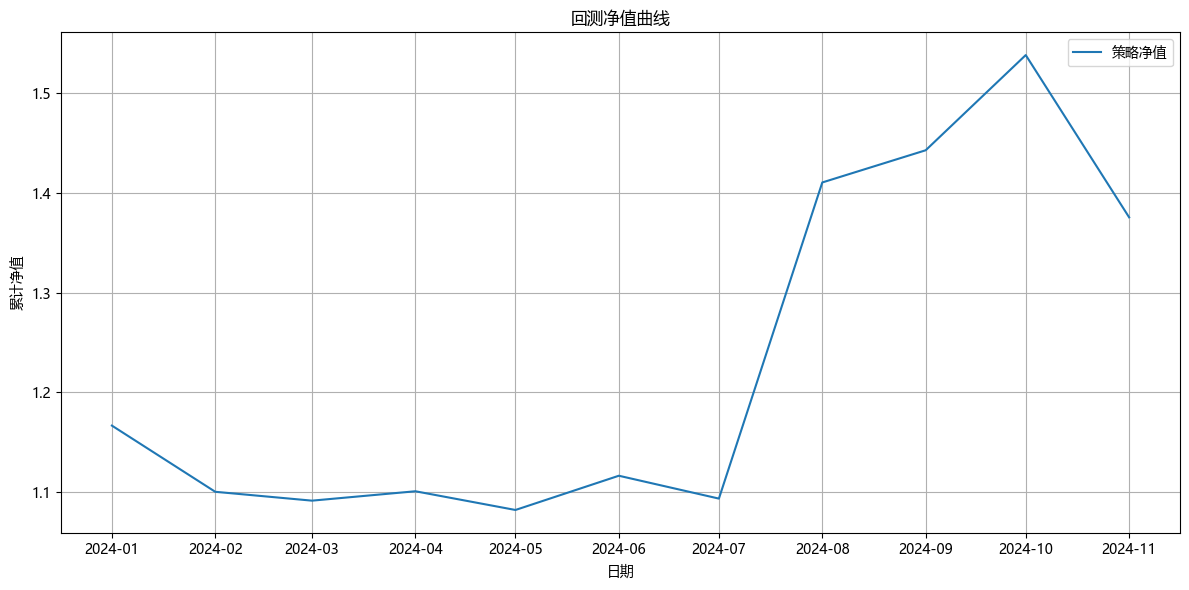

,strategy_return,strategy_nav
month,,
2024-01-01,0.166510,1.166510
2024-02-01,-0.056949,1.100078
2024-03-01,-0.008075,1.091195
2024-04-01,0.008632,1.100614
2024-05-01,-0.017059,1.081839
2024-06-01,0.031757,1.116195
2024-07-01,-0.020545,1.093262
2024-08-01,0.290165,1.410489
2024-09-01,0.022903,1.442794


In [4]:
test_df = pd.read_csv('test_set_predictions.csv', parse_dates=['date']) #读取测试集数据
backtest_monthly_strategy_with_trades(test_df, top_n=10, benchmark_returns=None, rf=0.0) #运行回测策略

# 计算回测指标

In [5]:
#获取沪深300指数
import atrader as at
dfData=at.get_kdata(target_list=['sse.000300'], frequency='month', fre_num=1, begin_date='2023-12-01', end_date='2024-12-31',fq=1,fill_up=False, df=True,sort_by_date=False)
print(dfData)

                  time        code       open       high        low      close       volume       amount open_interest
0  2023-12-29 15:00:00  sse.000300  3494.2234  3494.2234  3283.9883  3431.1099  2.14233e+09  3.49029e+12           NaN
1  2024-01-31 15:00:00  sse.000300  3426.2684  3426.2684  3171.6329  3215.3518  2.86937e+09  4.28046e+12           NaN
2  2024-02-29 15:00:00  sse.000300  3202.2564  3521.6574  3108.3515  3516.0826  2.56699e+09  3.90100e+12           NaN
3  2024-03-29 15:00:00  sse.000300  3515.0587  3610.7389  3489.3861  3537.4843  3.03140e+09  5.38461e+12           NaN
4  2024-04-30 15:00:00  sse.000300  3551.5815  3645.8229  3470.0611  3604.3943  3.10513e+09  4.76318e+12           NaN
5  2024-05-31 15:00:00  sse.000300  3654.0485  3703.0287  3579.9247  3579.9247  2.87391e+09  4.45113e+12           NaN
6  2024-06-28 15:00:00  sse.000300  3577.3798  3625.0109  3440.6464  3461.6570  2.37882e+09  3.89212e+12           NaN
7  2024-07-31 15:00:00  sse.000300  3458.2636  3

In [6]:
#计算回测策略指标
def backtest_monthly_with_metrics(test_df, top_n=10, benchmark_returns=None, rf=0.0):
    test_df = test_df.copy()
    test_df['month'] = test_df['date'].dt.to_period('M')

    monthly_returns = []
    for month, group in test_df.groupby('month'):
        top_stocks = group.sort_values(by='prediction', ascending=False).head(top_n)
        avg_return = top_stocks['fwd_return'].mean()
        monthly_returns.append({'month': month, 'strategy_return': avg_return})
    benchmark_returns = benchmark_returns.resample('M').last()  
    perf_df = pd.DataFrame(monthly_returns)
    perf_df['month'] = perf_df['month'].dt.to_timestamp('M')  # 月末日期
    perf_df = perf_df.set_index('month')
    if benchmark_returns is not None:
        perf_df['benchmark_return'] = benchmark_returns.loc[perf_df.index]
    else:
        perf_df['benchmark_return'] = 0.0

    # 后续保持不变
    perf_df['strategy_nav'] = (1 + perf_df['strategy_return']).cumprod()
    perf_df['benchmark_nav'] = (1 + perf_df['benchmark_return']).cumprod()
    
    # 净值计算
    perf_df['strategy_nav'] = (1 + perf_df['strategy_return']).cumprod()
    perf_df['benchmark_nav'] = (1 + perf_df['benchmark_return']).cumprod()

    # ===================== 核心指标计算 =====================
    excess_ret = perf_df['strategy_return'] - rf / 12
    excess_benchmark = perf_df['benchmark_return'] - rf / 12

    # 夏普比率
    sharpe = excess_ret.mean() / excess_ret.std() * np.sqrt(12)

    # 收益率/年化收益率
    total_return = perf_df['strategy_nav'].iloc[-1] - 1
    annual_return = (perf_df['strategy_nav'].iloc[-1]) ** (12 / len(perf_df)) - 1

    # 基准年化收益率
    benchmark_total_return = perf_df['benchmark_nav'].iloc[-1] - 1
    benchmark_annual_return = (perf_df['benchmark_nav'].iloc[-1]) ** (12 / len(perf_df)) - 1

    # 阿尔法和贝塔（线性回归）
    X = excess_benchmark.values.reshape(-1, 1)
    y = excess_ret.values
    model = LinearRegression().fit(X, y)
    alpha = model.intercept_ * 12  # 年化
    beta = model.coef_[0]

    # 收益波动率
    volatility = perf_df['strategy_return'].std() * np.sqrt(12)

    # 信息比率
    ir = (perf_df['strategy_return'] - perf_df['benchmark_return']).mean() / \
         (perf_df['strategy_return'] - perf_df['benchmark_return']).std()

    # 胜率
    win_rate = (perf_df['strategy_return'] > 0).mean()

    # 盈亏比
    pos = perf_df[perf_df['strategy_return'] > 0]['strategy_return']
    neg = perf_df[perf_df['strategy_return'] < 0]['strategy_return']
    pnl_ratio = pos.mean() / abs(neg.mean()) if not neg.empty else np.nan

    # 最大回撤
    max_drawdown = (perf_df['strategy_nav'] / perf_df['strategy_nav'].cummax() - 1).min()

    # ===================== 输出结果 =====================
    print("===== 回测指标汇总 =====")
    print(f"总收益率           : {total_return:.2%}")
    print(f"年化收益率         : {annual_return:.2%}")
    print(f"基准年化收益率     : {benchmark_annual_return:.2%}")
    print(f"阿尔法（年化）     : {alpha:.2%}")
    print(f"贝塔               : {beta:.2f}")
    print(f"夏普比率           : {sharpe:.2f}")
    print(f"收益波动率         : {volatility:.2%}")
    print(f"信息比率           : {ir:.2f}")
    print(f"最大回撤           : {max_drawdown:.2%}")
    print(f"胜率（>0的月比例） : {win_rate:.2%}")
    print(f"盈亏比             : {pnl_ratio:.2f}")

    # ===================== 可视化 =====================
    plt.figure(figsize=(12, 6))
    plt.plot(perf_df['strategy_nav'], label='策略净值')
    plt.plot(perf_df['benchmark_nav'], label='基准净值', linestyle='--')
    plt.title('策略 vs 基准净值曲线')
    plt.xlabel('月份')
    plt.ylabel('净值')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return perf_df


In [ ]:
# 计算沪深300指数基准收益率
df_hs300=dfData
df_hs300['time'] = pd.to_datetime(df_hs300['time'])
df_hs300 = df_hs300.sort_values('time')
df_hs300.set_index('time', inplace=True)

# 计算沪深300月度收益率
benchmark_nav = df_hs300['close']
benchmark_returns = benchmark_nav.pct_change().dropna()

# 对齐数据时间
benchmark_returns.index = benchmark_returns.index.normalize()
test_df['benchmark_return'] = test_df['date'].map(benchmark_returns)
test_df['date'] = pd.to_datetime(test_df['date'])

===== 回测指标汇总 =====
总收益率           : 37.55%
年化收益率         : 41.59%
基准年化收益率     : 15.53%
阿尔法（年化）     : 50.23%
贝塔               : -0.52
夏普比率           : 1.09
收益波动率         : 37.97%
信息比率           : 0.13
最大回撤           : -10.58%
胜率（>0的月比例） : 54.55%
盈亏比             : 2.34


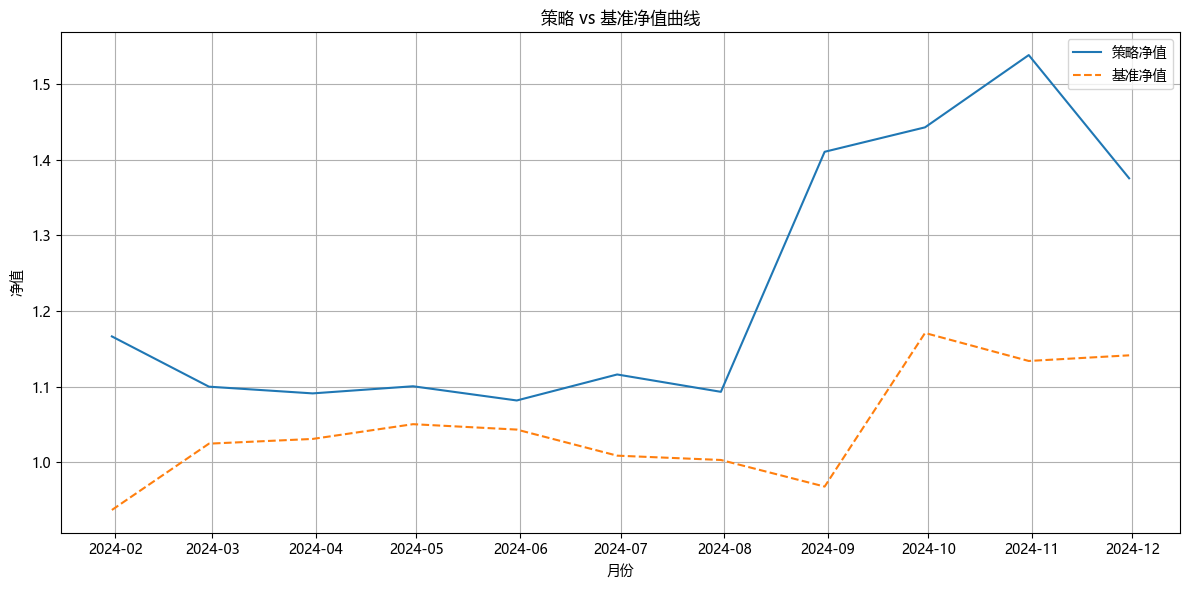

,strategy_return,benchmark_return,strategy_nav,benchmark_nav
month,,,,
2024-01-31,0.16651,-0.06288,1.16651,0.93712
2024-02-29,-0.05695,0.09353,1.10008,1.02477
2024-03-31,-0.00808,0.00609,1.09119,1.03100
2024-04-30,0.00863,0.01891,1.10061,1.05050
2024-05-31,-0.01706,-0.00679,1.08184,1.04337
2024-06-30,0.03176,-0.03304,1.11619,1.00890
2024-07-31,-0.02055,-0.00565,1.09326,1.00320
2024-08-31,0.29017,-0.03505,1.41049,0.96803
2024-09-30,0.02290,0.20968,1.44279,1.17101


In [8]:
backtest_monthly_with_metrics(test_df, top_n=10, benchmark_returns=benchmark_returns, rf=0.0) #运行回测策略